# Práctica 1 - Visión por Computador
## Marcial Galván - Alejandra Rodríguez

### Tabla de contenidos
- [Tarea 1 - Tablero de ajedrez](#tarea-1---tablero-de-ajedrez)
    - [De forma manual](#de-forma-manual)
    - [Con inteligencia artificial](#con-inteligencia-artificial)
- [Tarea 2 - Arte al estilo de Mondrian](#tarea-2---arte-al-estilo-de-mondrian)
- [Tarea 3 - Detección de píxeles en vídeo](#tarea-3---detección-de-píxeles-en-vídeo)
- [Tarea 4 - Pop Art al estilo de Warhol](#tarea-4---pop-art-al-estilo-de-warhol)

In [1]:
import cv2  
import numpy as np
import matplotlib.pyplot as plt
import random

### Tarea 1 - Tablero de ajedrez

Crear una imagen de 800x800 píxeles con la textura del tablero de ajedrez.

In [ ]:
width = 800
height = 600

#### De forma manual

In [ ]:
class Chess:
    def __init__(self, width, height, rows, cols):
        self.width = width
        self.height = height
        self.rows = rows
        self.cols = cols
        self.image = self.__draw()
    
    def __draw(self):
        
    
    def plot(self):
        plt.imshow(self.image, cmap="gray") 
        plt.show()



#### Con inteligencia artificial

In [ ]:
# Claude
# --- Parámetros ---
SQUARES = 8          # número de casillas por lado (tablero clásico 8x8)
SQ = width // SQUARES  # tamaño de cada casilla en píxeles
 
LIGHT = 255  # blanco
DARK = 0     # negro
 
# --- Construcción del patrón con numpy ---
# Índices de fila/columna de casilla para cada píxel
rows = np.arange(height) // SQ
cols = np.arange(width) // SQ
 
# Máscara booleana: True donde (fila+columna) es par -> casilla clara
row_grid, col_grid = np.meshgrid(rows, cols, indexing="ij")
mask = (row_grid + col_grid) % 2 == 0
 
# Imagen en escala de grises: un solo canal (width, height)
img = np.where(mask, LIGHT, DARK).astype(np.uint8)
 
# --- Visualización con matplotlib ---
fig, ax = plt.subplots(figsize=(width / 100, height / 100), dpi=100)
ax.imshow(img, cmap="gray", vmin=0, vmax=255)
ax.axis("off")
fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
 
plt.show()

In [ ]:
# ChatGPT
# Create an 8x8 chessboard using only grayscale values
board = np.indices((8, 8)).sum(axis=0) % 2

fig, ax = plt.subplots(figsize=(width / 100, height / 100), dpi=100)

# Map 0 -> white and 1 -> gray, with a grayscale colormap
ax.imshow(board, cmap="gray", vmin=0, vmax=1, interpolation="nearest")

# Remove axes, ticks, and margins
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect("equal")
fig.subplots_adjust(left=0, right=1, bottom=0, top=1)

plt.show()

In [ ]:
# Gemini
# Create an 8x8 checkerboard pattern (0 = black, 255 = white)
# Shape is (8, 8), single-channel uint8 array
board_8x8 = np.fromfunction(lambda i, j: (i + j) % 2 * 255, (8, 8), dtype=np.uint8)

# Scale up each 1x1 tile to 100x100 pixels to achieve an 800x800 resolution
chessboard = np.repeat(np.repeat(board_8x8, 100, axis=0), 100, axis=1)

# Set figure size to 8x8 inches at 100 DPI for exactly 800x800 pixels
plt.figure(figsize=(width / 100, height / 100), dpi=100)

# Render as grayscale (1 single color channel)
plt.imshow(chessboard, cmap='gray', vmin=0, vmax=255)

# Hide axes tick marks and borders
plt.axis('off')
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

plt.show()

### Tarea 2 - Arte al estilo de Mondrian

In [2]:
width = 300
height = 200

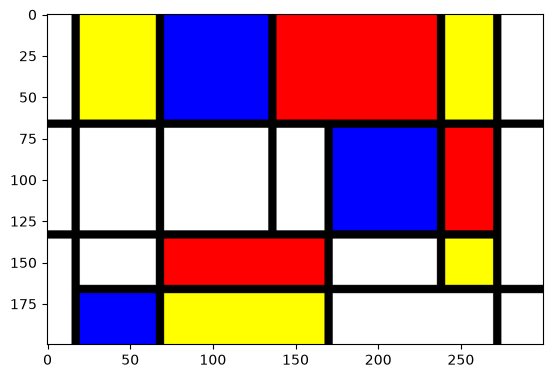

In [30]:
def add_horizontal_lines():
    cv2.line(mondrian_img, (0, layers[0]), (width, layers[0]), line_color, 3)
    cv2.line(mondrian_img, (0, layers[1]), (x_step*16, layers[1]), line_color, 3)
    cv2.line(mondrian_img, (columns[0], layers[2]), (width, layers[2]), line_color, 3)

def add_vertical_lines():    
    cv2.line(mondrian_img, (columns[0], 0), ((columns[0], height)), line_color, 3)
    cv2.line(mondrian_img, (columns[1], 0), ((columns[1], height)), line_color, 3)
    cv2.line(mondrian_img, (columns[2], 0), ((columns[2], layers[1])), line_color, 3)
    cv2.line(mondrian_img, (columns[4], 0), ((columns[4], layers[2])), line_color, 3)
    cv2.line(mondrian_img, (columns[5], 0), ((columns[5], height)), line_color, 3)
    cv2.line(mondrian_img, (columns[3], layers[0]), (columns[3], height), line_color, 3)

def paint_rectangle():
    cv2.rectangle(mondrian_img, (columns[0],0), (columns[1], layers[0]),(255, 255, 0),-1)
    cv2.rectangle(mondrian_img, (columns[1],0), (columns[2], layers[0]),(0, 0, 255),-1)
    cv2.rectangle(mondrian_img, (columns[2],0), (columns[4], layers[0]),(255, 0, 0),-1)
    cv2.rectangle(mondrian_img, (columns[4],0), (columns[5], layers[0]),(255, 255, 0),-1)
    cv2.rectangle(mondrian_img, (columns[4],0), (columns[5], layers[0]),(255, 255, 0),-1)
    cv2.rectangle(mondrian_img, (columns[3],layers[0]),(columns[4],layers[1]),(0, 0, 255),-1)
    cv2.rectangle(mondrian_img, (columns[4],layers[0]),(columns[5],layers[1]),(255, 0, 0),-1)
    cv2.rectangle(mondrian_img, (columns[1],layers[1]),(columns[3],layers[2]),(255, 0, 0),-1)
    cv2.rectangle(mondrian_img, (columns[4],layers[1]),(columns[5],layers[2]),(255, 255, 0),-1)
    cv2.rectangle(mondrian_img, (columns[0],layers[2]),(columns[1],height),(0, 0, 255),-1)
    cv2.rectangle(mondrian_img, (columns[1],layers[2]),(columns[3],height),(255, 255, 0),-1)


line_color = (0, 0, 0)
x_step = int(width/17)
columns=[x_step, x_step*4, x_step*8, x_step*10, x_step*14, x_step*16]
layers=[int(height/3), int((height/3)*2), int((height/6)*5)]
mondrian_img = np.full((height,width,3), 255, dtype = np.uint8)

paint_rectangle()
add_horizontal_lines()
add_vertical_lines()

plt.imshow(mondrian_img) 
plt.show()




In [3]:
def paint_mondrian(width, height):
    color_img = np.full((height,width,3), 255, dtype = np.uint8)

    colors = [(255, 0, 0), (0, 0, 255), (255, 255, 0), (255, 255, 255), (255, 255, 255)]
    lines = [((0, 0), (width, 0)), ((0, 0), (0, height)), ((width-1, 0), (width-1, height)), ((0, height-1), (width, height-1))]

    y_coord = 0

    while y_coord < height:
        y_step = min(random.randint(height // 6, height // 2), height - y_coord)
        lines.append(((0, y_coord), (width, y_coord)))

        x_coord = 0
        while x_coord < width:
            x_step = min(random.randint(10, width // 2), width - x_coord)
            cv2.rectangle(color_img, (x_coord, y_coord), (x_coord + x_step, y_coord + y_step), random.choice(colors), -1)
            lines.append(((x_coord, y_coord), (x_coord, y_coord + y_step)))
            x_coord += x_step

        y_coord += y_step

    for line in lines:
        cv2.line(color_img, line[0], line[1], (0, 0, 0), 3)

    return color_img

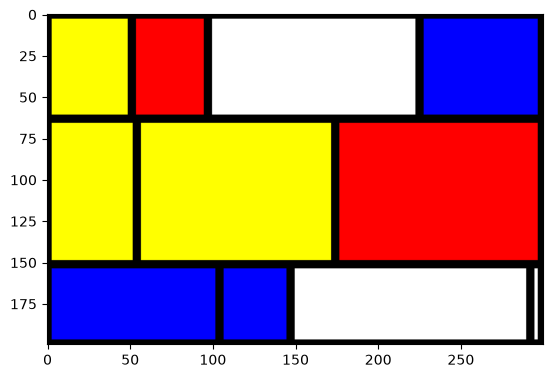

In [21]:
plt.imshow(paint_mondrian(width, height))
plt.show()

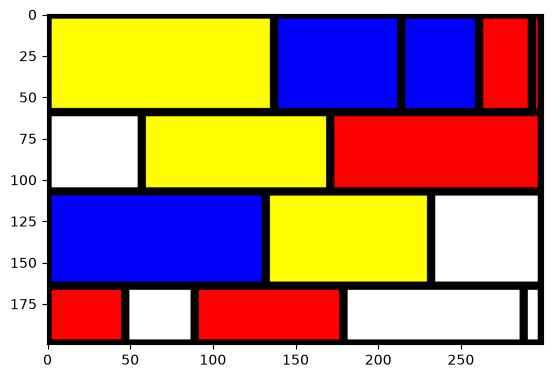

In [18]:
cv2.imwrite('mondrian.png', cv2.cvtColor(paint_mondrian(width, height), cv2.COLOR_BGR2RGB))
img = cv2.cvtColor(cv2.imread('mondrian.png'), cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.show()

### Tarea 3 - Detección de píxeles en vídeo

### Tarea 4 - Pop Art al estilo de Warhol

### Tarea Extra

In [22]:
vid = cv2.VideoCapture(0)
while(True):
    ret, frame = vid.read() # frame = 480x640x3
    if ret:
        bordes = cv2.Canny(frame, 100, 150) # bordes = 480x640
        for y  in range(len(frame)):
            if(np.sum(bordes[y]) != 0):
                for x in range(len(frame[y])):
                    frame[y][x][0] *= bordes[y][x]
                    frame[y][x][1] *= bordes[y][x]
                    frame[y][x][2] *= bordes[y][x]

        cv2.imshow('Cam', frame)

        


    if cv2.waitKey(20) == 27:
        break
  
# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()

C:\Users\aleja\AppData\Local\Temp\ipykernel_15932\428286522.py:9: RuntimeWarning: overflow encountered in scalar multiply
  frame[y][x][0] *= bordes[y][x]
C:\Users\aleja\AppData\Local\Temp\ipykernel_15932\428286522.py:10: RuntimeWarning: overflow encountered in scalar multiply
  frame[y][x][1] *= bordes[y][x]
C:\Users\aleja\AppData\Local\Temp\ipykernel_15932\428286522.py:11: RuntimeWarning: overflow encountered in scalar multiply
  frame[y][x][2] *= bordes[y][x]
